In [21]:
import torch
from torch.utils import data
from tcn import TCN, BranchedTCN
import dataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import precision_score, recall_score
import config
import os

# Get GPU if possible, else get CPU
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU! Using CPU only")

Using the GPU!


### Prepare For Evaluation
#### Grab the evaluation dataloaders

In [16]:
dl = dataLoader.get_dataloaders(data_dir=config.data_dir, 
                                batch_size=128, 
                                max_range=config.max_range, 
                                shuffle=False, 
                                transform=dataLoader.get_image_transforms(),
                                squeeze=True,
                                hpf=True)

#### Load the desired model checkpoint

In [33]:
model = BranchedTCN(input_size=232, output_size=2, num_channels=[368]*9, kernel_size=6, dropout=0.35).to(device)
#model = TCN(input_size=232, output_size=2, num_channels=[368]*9, kernel_size=6, dropout=0.35).to(device)
model.load_state_dict(torch.load(os.path.join(config.models_dir + '/L2Norm', 'weights_67.pt'), map_location=device)['model_state_dict'])

<All keys matched successfully>

### Evaluate Model On Synthetic Data
#### Get Predictions and Labels

In [3]:
def evaluate_model(model, dataloader, thresh=0.5, save_data=False):
    
    """
    Get predicted and ground truth values for range and class using a given model and dataloader
    
    Parameters
    ----------
    model: nn.Module, input model to be evaluated
    dataloader: torch.utils.data.DataLoader, dataloader for dataset to be used to evaluate model
    
    Returns
    -------
    ranges_p: array-like, predicted ranges
    ranges_t array-like, true classes
    class_p: array-like, predicted ranges
    class_t: array-like, true classes
    """
    
    # Put model in eval mode
    model.eval()
    
    # Store true labels
    ranges_t = []
    ranges_p = []
    class_t = []
    class_p = []
    
    # Store data
    X = []
    
    for inputs, r_labels, c_labels in tqdm(dataloader):

        inputs = inputs.to(device)
        r_labels = r_labels.to(device).squeeze()
        c_labels = c_labels.to(device).squeeze()

        with torch.set_grad_enabled(False):

            outputs = model(inputs)
            ranges_p += (outputs[:,0].squeeze()*config.max_range).detach().tolist()
            ranges_t += (r_labels.squeeze()*config.max_range).detach().tolist()
            class_p += (outputs[:,1] >= thresh).tolist()
            class_t += c_labels.tolist()
            if save_data:
                X += inputs.tolist()

    ranges_p = np.asarray(ranges_p)
    ranges_t = np.asarray(ranges_t)
    ranges_t[ranges_t < 0] = -1
    class_p = np.asarray(class_p)
    class_t = np.asarray(class_t)
    X = np.asarray(X)
    
    return ranges_p, ranges_t, class_p, class_t, X

In [17]:
# evaluate
ranges_p, ranges_t, class_p, class_t, _ = evaluate_model(model, dl['test'], thresh=0.5, save_data=False)

# get some stats
p = precision_score(class_t, class_p)
r = recall_score(class_t, class_p)
a = (class_t == class_p).sum() / len(class_t)
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/577 [00:00<?, ?it/s]

Accuracy: 0.9966
Precision: 0.9999
Recall: 0.9934


#### Plot Predicted Ranges of Detections Vs. Ground Truth

In [4]:
def plot_true_pred(ranges_t, ranges_p, class_t, class_p, markersize=1):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    plt.plot(ranges_t, ranges_p, 'o', markersize=markersize, label="range predictions")
    plt.plot([0, config.max_range], [0, config.max_range], '--r', label="ideal mapping")
    plt.grid()
    plt.legend()
    plt.xlabel("True Range [m]")
    plt.ylabel("Predicted Range [m]")
    plt.show()
    
    MSE = ((ranges_t - ranges_p) ** 2).mean()
    RMSE = np.sqrt(MSE)
    MAPE = (np.abs(ranges_t - ranges_p) / ranges_t).mean()
    MAE = np.abs(ranges_t - ranges_p).mean()
    
    print("MSE: {:.2f} m".format(MSE))
    print("RMSE: {:.2f} m".format(RMSE))
    print("MAPE: {:.4f}".format(MAPE))
    print("MAE: {:.2f} m".format(MAE))

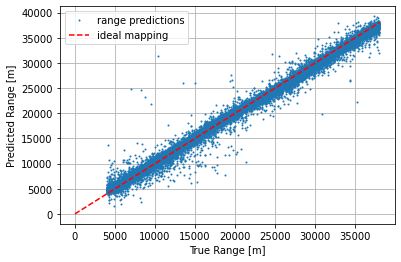

MSE: 580736.36 m
RMSE: 762.06 m
MAPE: 0.0329
MAE: 501.85 m


In [19]:
plot_true_pred(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Standard Deviation + Error

In [5]:
def plot_intra_range_std(ranges_t, ranges_p, class_t, class_p):

    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get standard deviation of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    std_list = [np.std(ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, std_list)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("STD of Predicted Ranges [m]")
    plt.show()
    return std_list

def plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list):
    
    # isolate true positives
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get average error of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    avg_err = [np.mean(r - ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, avg_err, label="Average Error")
    plt.fill_between(np.asarray(unique_ranges), np.asarray(avg_err) - np.asarray(std_list), np.asarray(avg_err) + np.asarray(std_list), alpha=0.3, label="$\pm 1~SD$")
    plt.grid()
    plt.legend()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("Average Error of Predicted Ranges [m]")
    plt.show()

In [6]:
std_list = plot_intra_range_std(ranges_t, ranges_p, class_t, class_p)
plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list)

NameError: name 'ranges_t' is not defined

#### Display Top-k Highest Error Calls

In [6]:
def display_high_error(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    # isolate true positives
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 1))[0],...]
    
    # Get indices of top-k highest-error calls
    top_k_abs_err = np.abs(ranges_calls_t - ranges_calls_p)
    inds = top_k_abs_err.argsort()[::-1][:k]
    
    # Get error values and correspinding spectrograms
    top_k_abs_err = top_k_abs_err[inds]
    top_k_err_X = dataset[inds, ...]
    range_calls_t_filt = ranges_calls_t[inds]
    
    import plotter
    plotter.plot_grid(top_k_err_X, top_k_abs_err, label_text="Err:", title="High Error Calls", dim=dim, randomize=False)

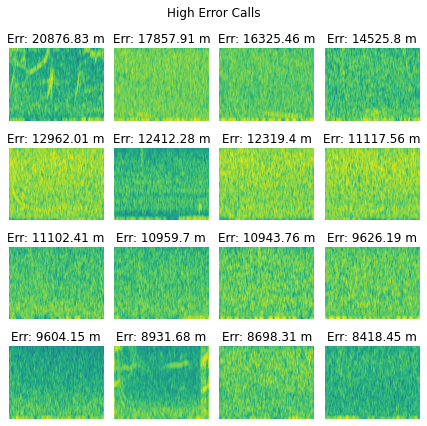

In [23]:
display_high_error(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

#### Plot False Negatives

In [7]:
def display_FNs(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    ranges_calls_t = ranges_t[np.where((class_p == 0) & (class_t == 1))]
    ranges_calls_p = ranges_p[np.where((class_p == 0) & (class_t == 1))]
    dataset = dataset[np.where((class_p == 0) & (class_t == 1))[0],...]
    
    import plotter
    plotter.plot_grid(dataset, ranges_calls_p, label_text="Range_p:", title="FNs", dim=dim, sub_titles=False, randomize=False)

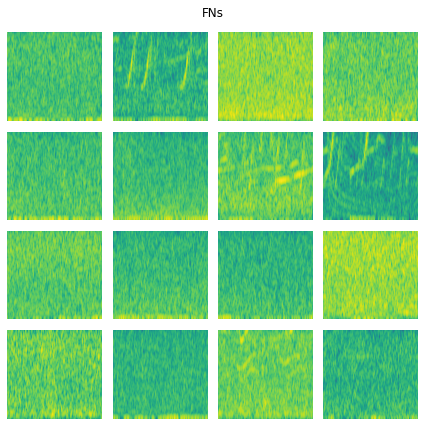

In [25]:
display_FNs(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

#### Plot False Negatives

In [8]:
def display_FPs(ranges_t, ranges_p, class_t, class_p, dataset, k=16, dim=(4,4)):
    
    ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 0))]
    ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 0))]
    dataset = dataset[np.where((class_p == 1) & (class_t == 0))[0],...]
    
    import plotter
    plotter.plot_grid(dataset, ranges_calls_p, label_text="Range_p:", title="FPs", dim=dim, sub_titles=False, randomize=False)

In [8]:
display_FPs(ranges_t, ranges_p, class_t, class_p, dl['test'].dataset.inputs['data'])

NameError: name 'display_FPs' is not defined

### Evaluate Model On Experimental Data
#### Put Warped Data Into A Dataloader

In [9]:
warp_dataset = dataLoader.Warped(dir_path=config.exp_data, 
                                 max_range=config.max_range, 
                                 transform=dataLoader.get_image_transforms()['eval'], 
                                 squeeze=True,
                                 hpf=False)

warp_dl = {'test': data.DataLoader(warp_dataset, batch_size=5, shuffle=False)}

#### Evalutate Model On Experimental Data

In [34]:
# evaluate the model
warp_ranges_p, warp_ranges_t, warp_class_p, warp_class_t, X = evaluate_model(model, warp_dl['test'], thresh=0.5, save_data=True)

# filter so that true ranges are within the bounds of the training data
inds = np.where((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range) & (warp_ranges_t != -1))
inds_fnfp = np.where((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range) | (warp_ranges_t == -1))
# Filter out calls within range of trining data and the noise examples
acc_inds = np.where(((warp_ranges_t <= config.max_range) & (warp_ranges_t >= config.min_range)) | (warp_ranges_t == -1))

# get calls in range of training data
warp_ranges_p_filt = warp_ranges_p[inds[0]] 
warp_class_t_filt = warp_class_t[inds[0]] 
warp_class_p_filt = warp_class_p[inds[0]]
warp_ranges_t_filt = warp_ranges_t[inds[0]]
dataset = warp_dl['test'].dataset.inputs['data']
dataset_filt = dataset[inds[0],...]
print(f"{warp_class_p_filt.sum()} / {warp_class_t_filt.sum()} calls detected")

# Get some stats with in-range calls and noise examples
p = precision_score(warp_class_t[acc_inds[0]], warp_class_p[acc_inds[0]])
r = recall_score(warp_class_t[acc_inds[0]], warp_class_p[acc_inds[0]])
a = (warp_class_t[acc_inds[0]] == warp_class_p[acc_inds[0]]).sum() / len(warp_class_t[acc_inds[0]])
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/22 [00:00<?, ?it/s]

37 / 50.0 calls detected
Accuracy: 0.8700
Precision: 1.0000
Recall: 0.7400


#### Plot Predicted Ranges of Detections Vs. Ground Truth

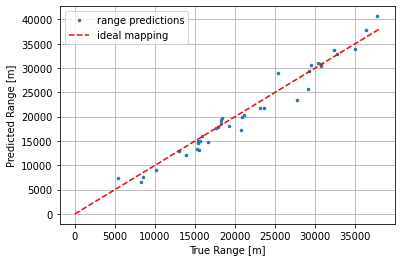

MSE: 2852186.83 m
RMSE: 1688.84 m
MAPE: 0.0734
MAE: 1306.54 m


In [35]:
plot_true_pred(warp_ranges_t_filt, warp_ranges_p_filt, warp_class_t_filt, warp_class_p_filt, markersize=2.5)

#### Display Top-k Highest Error Calls

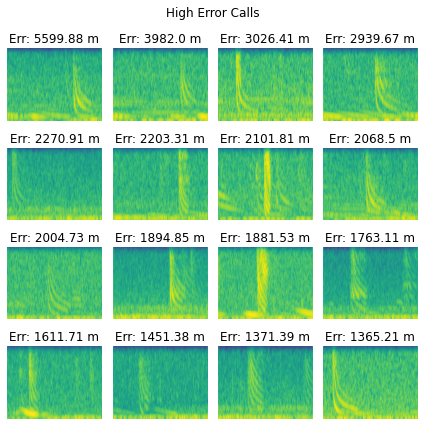

In [28]:
display_high_error(warp_ranges_t_filt, warp_ranges_p_filt, warp_class_t_filt, warp_class_p_filt, dataset_filt)

#### Display False Negatives

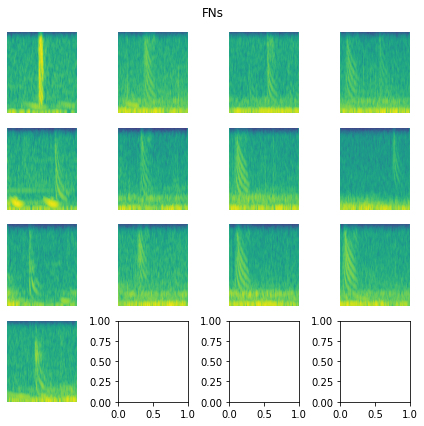

In [29]:
display_FNs(warp_ranges_t[inds_fnfp[0]], warp_ranges_p[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], warp_class_p[inds_fnfp[0]], dataset[inds_fnfp[0]])

#### Display False Positives

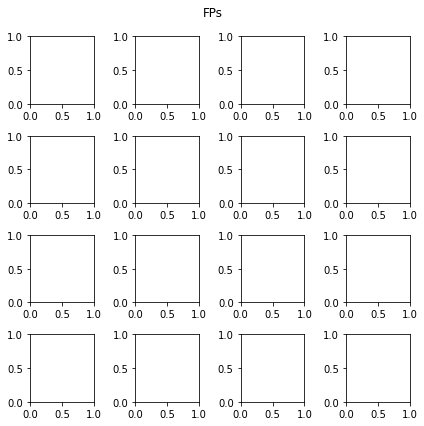

In [14]:
display_FPs(warp_ranges_t[inds_fnfp[0]], warp_ranges_p[inds_fnfp[0]], warp_class_t[inds_fnfp[0]], warp_class_p[inds_fnfp[0]], dataset[inds_fnfp[0]])